In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from toy_image_generator import get_toy_image_example_batch
from diffuser_ddpm_linear_schedule import Diffuser_DDPM_linear_schedule

toy_image_batch = get_toy_image_example_batch(
    x_dim=256,
    y_dim=256,
    hue_1s=np.array([0]),
    saturation_1s=np.array([255]),
    value_1s=np.array([255]),
    hue_2s=np.array([90]),
    saturation_2s=np.array([255]),
    value_2s=np.array([255]),
    hue_3s=np.array([0]),
    saturation_3s=np.array([0]),
    value_3s=np.array([0]),
    angles=np.array([45]),
    line_widths=np.array([5])
)

x_0 = toy_image_batch[0]

In [6]:
ddpm_model = Diffuser_DDPM_linear_schedule(total_timesteps=1000, beta_start=0.0001, beta_end=0.02)

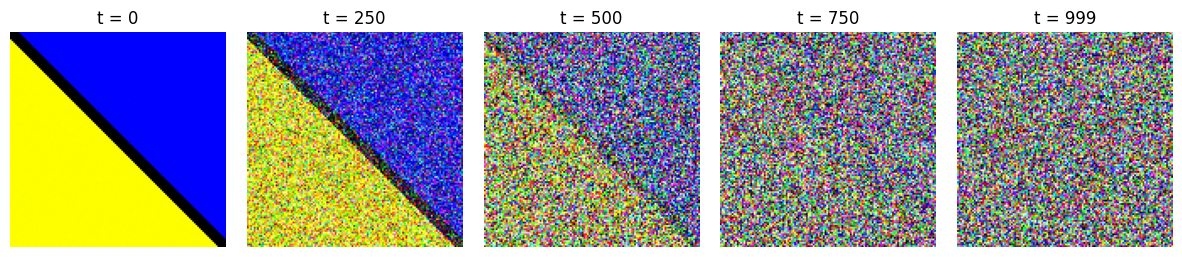

In [7]:
timesteps = [0, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 5))
plt.subplots_adjust(wspace=0.1)

for i, t in enumerate(timesteps):

    ts = torch.tensor([t]).to(x_0.device)

    x_t, _ = ddpm_model.forward_diffusion(x_0, ts)

    # Prepare image for display: 
    x_t_vis = (x_t.squeeze() + 1.0) / 2.0
    x_t_vis = (x_t_vis * 255.0).clamp(0, 255).byte()
    display_img = x_t_vis.permute(1, 2, 0).cpu().numpy()

    # Plot
    axes[i].imshow(display_img)
    axes[i].set_title(f"t = {t}")
    axes[i].axis("off")

plt.show()

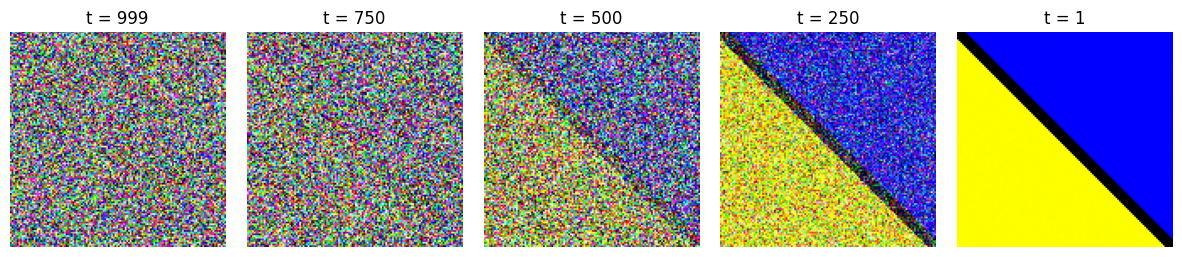

In [8]:
visualize_steps = [999, 750, 500, 250, 1]
denoise_from_t = 999

fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 5))
plt.subplots_adjust(wspace=0.1)

ts = torch.tensor([denoise_from_t]).to(x_0.device)
x_t, _ = ddpm_model.forward_diffusion(x_0, ts)

plot_idx = 0

for i, t in enumerate(reversed(range(1, denoise_from_t + 1))):

    ts = torch.tensor([t]).to(x_0.device)

    a_bar = ddpm_model.alpha_bars[t]
    noise_pred = (x_t - torch.sqrt(a_bar) * x_0) / torch.sqrt(1 - a_bar)

    x_t = ddpm_model.reverse_diffusion(x_t, ts, noise_pred)

    if t in visualize_steps:

        # Prepare image for display: 
        x_t_vis = (x_t.squeeze() + 1.0) / 2.0
        x_t_vis = (x_t_vis * 255.0).clamp(0, 255).byte()
        display_img = x_t_vis.permute(1, 2, 0).cpu().numpy()

        # Plot
        axes[plot_idx].imshow(display_img)
        axes[plot_idx].set_title(f"t = {t}")
        axes[plot_idx].axis("off")
        plot_idx += 1
    
plt.show()